## 드라이브 마운트 및 경로 추가

In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
%cd /content/drive/MyDrive/ultralytics/ultralytics
%ls

/content/drive/MyDrive/ultralytics/ultralytics
assets/                      NHC014_YOLO.ipynb  trackers/
cfg/                         NHC_DETECT/        utils/
data/                        nn/                wandb/
engine/                      __pycache__/       yolo11n.pt
FOOD_DETECT/                 rtdetr-l.pt        yolo11s.pt
Food_Detection_RTDETR.ipynb  rtdetr-x.pt        yolov8m.pt
Food_Detection_YOLO.ipynb    runs/              yolov8n.pt
hub/                         runs_food_rtdetr/  yolov8n-seg.pt
__init__.py                  runs_food_yolo/    yolov8s.pt
models/                      runs_HNC_yolo/
NH01_YOLO.ipynb              solutions/


In [3]:
import sys
sys.path.append('/content/drive/MyDrive/ultralytics')
sys.path.append('/content/drive/MyDrive/ultralytics/ultralytics')  # Add the folder to sys.path

In [ ]:
#!mkdir custom_data
# !cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/default.yaml ./NHC_DETECT/default.yaml
# !cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/models/v8/yolov8.yaml ./NHC_DETECT/custom_yolov8.yaml

In [ ]:
#!cp /content/drive/MyDrive/ultralytics/ultralytics/cfg/models/11/yolo11.yaml ./NHC_DETECT/custom_yolo11.yaml

## 파일 개수 체크

In [ ]:
# !unzip -q -O cp949 /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID.zip -d /content/drive/MyDrive/ultralytics/ultralytics/NECK_HYOID
# -O cp949 부분은 한글깨짐 방지 코드

In [ ]:
train_image = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/images/train'
train_label = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/train'

In [ ]:
import os
file_count = len([file for file in os.listdir(train_image) if os.path.isfile(os.path.join(train_image, file))])
print(file_count)

9190


In [ ]:
label_count = len([file for file in os.listdir(train_label) if os.path.isfile(os.path.join(train_label, file))])
print(label_count)

9193


In [ ]:
val_image = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/images/valid'
val_label = '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid'

In [ ]:
file_count = len([file for file in os.listdir(val_image) if os.path.isfile(os.path.join(val_image, file))])
print(file_count)

2634


In [ ]:
label_count = len([file for file in os.listdir(val_label) if os.path.isfile(os.path.join(val_label, file))])
print(label_count)

2157


In [ ]:
from collections import defaultdict

def find_duplicate_filenames(directory_path):
    file_map = defaultdict(list)

    for root, _, files in os.walk(directory_path):
        for file in files:
            file_map[file].append(os.path.join(root, file))

    duplicates = {name: paths for name, paths in file_map.items() if len(paths) > 1}

    return duplicates

# Example usage
duplicates = find_duplicate_filenames(train_label)

if duplicates:
    print("Duplicate filenames found:")
    for name, paths in duplicates.items():
        print(f"File '{name}' found at:")
        for path in paths:
            print(f"  {path}")
else:
    print("No duplicate filenames found.")

No duplicate filenames found.


## GPU 체크

In [4]:
import gc
import torch
import yaml

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 모델 로드

In [6]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 37.3/235.7 GB disk)


In [7]:
from ultralytics import YOLO

In [8]:
#model1 = YOLO("yolov8n.pt") # Load a COCO-pretrained YOLOv8nano model
#model2 = YOLO("yolov8s.pt")  # Load a COCO-pretrained YOLOv8small model
#model3 = YOLO("yolo11n.pt")  # build from YAML and transfer weights
model4 = YOLO("yolo11s.pt")
# Display model information (optional)
model4.info()

YOLO11s summary: 319 layers, 9,458,752 parameters, 0 gradients


(319, 9458752, 0, 0.0)

# 설골,목뼈만



https://discuss.pytorch.kr/t/yolov5/1664/5

## YOLOv8 Nano Train1

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov8(n)_train1',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(n)_train1',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    run = wandb.init(project="HN_01_YOLO",
                 name = 'yolov8(n)_train1',
                 id='1i0b6xi3',
                 resume='allow',
                 config=args)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

    # Validate the model
    metrics = model.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml')
    metrics_dict = metrics.results_dict

    # Log metrics to WandB
    wandb.log({
        "val_precision": metrics_dict.get('metrics/precision(B)', 0),
        "val_recall": metrics_dict.get('metrics/recall(B)', 0),
        "val_mAP50": metrics_dict.get('metrics/mAP50(B)', 0),
        "val_mAP50-95": metrics_dict.get('metrics/mAP50-95(B)', 0),
        "train_loss": results.get('loss', 0),
        "val_loss": metrics_dict.get('val/loss', 0)
    })
    # Finish the WandB run
    wandb.finish()

if __name__ == "__main__":
  main(model1)

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.40 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(n)_train1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames

100%|██████████| 755k/755k [00:00<00:00, 91.9MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/train... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [21:12<00:00,  7.22it/s]

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:13<00:00,  6.05it/s]

                   all       2634      11834       0.79      0.958      0.861      0.596
            hyoid_bone       2021       2021      0.779      0.947      0.828      0.513
             neck_bone       2157       9813      0.801      0.969      0.893      0.679
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▃▄▃▄▇▆█▇█
metrics/mAP50-95(B),▁▅▅▃▇▆█▇▇█
metrics/precision(B),▁▄▆▅▆▆▇██▇
metrics/recall(B),▄▁▆▇▆▇█▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▅▅▄▃▃▂▂▁▁


Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 2,684,758 parameters, 0 gradients


FileNotFoundError: 
Dataset '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_014.yaml' images not found ⚠️, missing path '/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data/images/valid'
Note dataset download directory is '/content/drive/MyDrive/ultralytics/ultralytics/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
# Load a pretrained YOLO model
model_val1 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(n)_train1/weights/best.pt")

In [ ]:
# Run inference with the YOLOv8n model on the 'test_full.jpg' image
results = model_val1.predict(source="/content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg",
                        conf=0.25,
                        iou=0.5)


image 1/1 /content/drive/MyDrive/ultralytics/ultralytics/assets/test_full.jpg: 640x1088 1 hyoid_bone, 5 neck_bones, 68.9ms
Speed: 16.5ms preprocess, 68.9ms inference, 893.9ms postprocess per image at shape (1, 3, 640, 1088)


In [ ]:
for result in results:
  print(result.boxes)
  break

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 0., 1., 1.], device='cuda:0')
conf: tensor([0.9165, 0.9133, 0.9005, 0.8971, 0.8922, 0.8766], device='cuda:0')
data: tensor([[7.4956e+02, 4.3462e+02, 8.6012e+02, 5.5519e+02, 9.1653e-01, 1.0000e+00],
        [7.8433e+02, 5.0392e+02, 8.8946e+02, 6.2060e+02, 9.1327e-01, 1.0000e+00],
        [8.3504e+02, 5.7540e+02, 9.3691e+02, 7.0352e+02, 9.0050e-01, 1.0000e+00],
        [5.2687e+02, 5.8030e+02, 5.7201e+02, 6.4800e+02, 8.9708e-01, 0.0000e+00],
        [8.6533e+02, 6.3998e+02, 9.8244e+02, 7.6443e+02, 8.9217e-01, 1.0000e+00],
        [7.2830e+02, 3.4686e+02, 8.3416e+02, 4.8458e+02, 8.7663e-01, 1.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1920)
shape: torch.Size([6, 6])
xywh: tensor([[804.8417, 494.9060, 110.5638, 120.5681],
        [836.8971, 562.2615, 105.1245, 116.6869],
        [885.9767, 639.4605, 101.8655, 128.1144],
        [549.4426, 614.1497,  45.1381,  67.7037],
        [

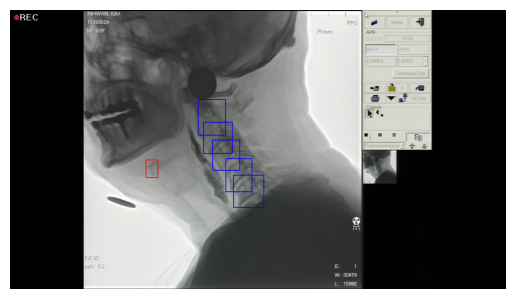

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 원본 이미지를 가져오기
image = results[0].orig_img

# 탐지된 모든 박스 좌표와 클래스 정보 가져오기
boxes = results[0].boxes.xyxy.cpu().numpy()  # 좌표를 NumPy 배열로 변환
classes = results[0].boxes.cls.cpu().numpy()  # 클래스 정보를 NumPy 배열로 변환

# 각 박스에 대해 루프
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box[:4]) # 좌표 추출
    cls = int(classes[i]) # 클래스 추출

    # 클래스에 따라 색상 설정
    if cls==0:
      color = (0,0,255) # 파란색:설골
    elif cls==1:
      color = (255,0,0) # 빨간색:목뼈
    else:
      color = (0,255,0) # 초록색:동전

    # 이미지에 박스 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

# 이미지 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 결과 이미지를 파일로 저장
plt.savefig(fname="/content/drive/MyDrive/ultralytics/ultralytics/runs_HN_yolo/predict/predict.png")
# 저장후, 보여주기. 순서가 바뀌면 빈 화면 저장하게 됌.
plt.show()

In [ ]:
metrics = model_val1.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:21<00:00,  7.77it/s]


                   all       2634      11834      0.791      0.957       0.86      0.596
            hyoid_bone       2021       2021       0.78      0.946      0.827      0.514
             neck_bone       2157       9813      0.801      0.968      0.893      0.679
Speed: 0.4ms preprocess, 2.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val


{'metrics/precision(B)': np.float64(0.7907782902709457),
 'metrics/recall(B)': np.float64(0.9568867305378572),
 'metrics/mAP50(B)': np.float64(0.8602818670709605),
 'metrics/mAP50-95(B)': np.float64(0.596313264608237),
 'fitness': np.float64(0.6227101248545093)}

## YOLOv8 Nano Train2

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov8(n)_train2',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(n)_train2',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    run = wandb.init(project="HN_01_YOLO",
                 name = 'yolov8(n)_train2',
                 config=args)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

    # Validate the model
    metrics = model.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
    metrics_dict = metrics.results_dict

    # Log metrics to WandB
    wandb.log({
        "val_precision": metrics_dict.get('metrics/precision(B)'),
        "val_recall": metrics_dict.get('metrics/recall(B)'),
        "val_mAP50": metrics_dict.get('metrics/mAP50(B)'),
        "val_mAP50-95": metrics_dict.get('metrics/mAP50-95(B)'),
        "train_loss": results.get('loss'),
        "val_loss": metrics_dict.get('val/loss')
    })
    # Finish the WandB run
    wandb.finish()

if __name__ == "__main__":
  main(model1)

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.41 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(n)_train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/images/train/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed


albumentations: 


...

val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/images/valid/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:40<00:00,  4.04it/s]

                   all       2634      11834      0.784      0.937      0.843      0.591
            hyoid_bone       2021       2021      0.769      0.905       0.79      0.492
             neck_bone       2157       9813      0.799       0.97      0.897      0.689
Speed: 0.4ms preprocess, 3.0ms inference, 0.0ms loss, 0.9ms postprocess per image


AttributeError: 'DetMetrics' object has no attribute 'get'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when the

In [ ]:
# Load a pretrained YOLO model
model_val2 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(n)_train2/weights/best.pt")

In [ ]:
metrics = model_val2.val(data="/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml")
metrics.results_dict

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 186 layers, 2,684,758 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:20<00:00,  7.87it/s]


                   all       2634      11834      0.784      0.937      0.843      0.591
            hyoid_bone       2021       2021      0.769      0.905       0.79      0.492
             neck_bone       2157       9813      0.799       0.97      0.897      0.689
Speed: 0.4ms preprocess, 2.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/val2


{'metrics/precision(B)': np.float64(0.784077653269613),
 'metrics/recall(B)': np.float64(0.9371609062080815),
 'metrics/mAP50(B)': np.float64(0.8434802267354888),
 'metrics/mAP50-95(B)': np.float64(0.5905177970801019),
 'fitness': np.float64(0.6158140400456407)}

## YOLOv8 Small Train3

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov8(n)_train3', # typing error, renamed to "train3_smallmodel"
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(s)_train3',
                plots=True)

    run = wandb.init(project="HN_01_YOLO",
                 name = 'yolov8(n)_train3',
                 config=args)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model2)

wandb: Currently logged in as: so0916a. Use `wandb login --relogin` to force relogin


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.43 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(n)_train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=

100%|██████████| 755k/755k [00:00<00:00, 129MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

...

                   all       2634      11834      0.788       0.96       0.83      0.595



10 epochs completed in 1.487 hours.
Optimizer stripped from runs/detect/yolov8(n)_train3/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/yolov8(n)_train3/weights/best.pt, 20.0MB

Validating runs/detect/yolov8(n)_train3/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:23<00:00,  3.49it/s]


                   all       2634      11834      0.788      0.951      0.863      0.607
            hyoid_bone       2021       2021      0.775      0.939      0.833      0.537
             neck_bone       2157       9813      0.801      0.963      0.893      0.677
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/yolov8(n)_train3


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▂▃▁▅█▃▃▅▂█
metrics/mAP50-95(B),▂▁▂▄█▆▅▆▅█
metrics/precision(B),▆▂▁▂▆▃▂██▆
metrics/recall(B),▃▅▁▇▇▆▇█▇▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▅▄▃▃▂▂▁▁


In [ ]:
# Load a pretrained YOLO model
mode_val3 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(n)_train3_smallmodel/weights/best.pt")

In [ ]:
# Validate the model
metrics = mode_val3.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:43<00:00,  3.77it/s]


                   all       2634      11834      0.788      0.951      0.863      0.608
            hyoid_bone       2021       2021      0.775      0.939      0.833      0.538
             neck_bone       2157       9813      0.801      0.963      0.893      0.678
Speed: 0.4ms preprocess, 6.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val3
0.7878836885818006


## YOLOv8 Small Train4

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov8(s)_train4',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(s)_train4',
                plots=True)

    run = wandb.init(project="HN_01_YOLO",
                 name = 'yolov8(s)_train4',
                 config=args)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model2)

lr/pg0,▁▅██▇▇▇▇
lr/pg1,▁▅██▇▇▇▇
lr/pg2,▁▅██▇▇▇▇
metrics/mAP50(B),▁▇▂█▃▁▄
metrics/mAP50-95(B),▃▇▃█▁▅▆
metrics/precision(B),▂█▁▁▄▄▆
metrics/recall(B),▁▆▆▇▆▄█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▅▄▃▂▂▁▁


Using device: cuda
New https://pypi.org/project/ultralytics/8.3.51 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov8(s)_train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/images/train/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/NECK_HYOID/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]


...

                   all       2634      11834      0.786      0.943      0.812       0.56



40 epochs completed in 3.276 hours.
Optimizer stripped from runs/detect/yolov8(s)_train4/weights/last.pt, 20.0MB
Optimizer stripped from runs/detect/yolov8(s)_train4/weights/best.pt, 20.0MB

Validating runs/detect/yolov8(s)_train4/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:23<00:00,  3.51it/s]


                   all       2634      11834      0.786      0.945      0.848      0.611
            hyoid_bone       2021       2021      0.767      0.944       0.81      0.524
             neck_bone       2157       9813      0.805      0.946      0.886      0.699
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/yolov8(s)_train4


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),█▅▆▄▃█▇▄▄█▅▆▆▃▅█▅▆▅▃▅▅▇▄▅▅▄▃▂▄▄▁▂▁▁▂▂▂▂█
metrics/mAP50-95(B),█▅▅▃▄▆▆▄▄█▆▇▆▅▆▇▅█▇▆▆▇█▆▇▇▃▃▁▄▃▁▁▁▁▂▁▂▂█
metrics/precision(B),▅▅▆▂▁▆▄▄▆▇▇▅▅▆▂▅▅▂▃▃▄▁▅▅▅▇█▇█▆▇▇▆█▇▇▇▇█▇
metrics/recall(B),█▄▂▄▁▅▇▅▆▇▆▃▄▃▆▂▆▇█▆█▇▆▅▅▄▅▆▇▆▆▃▆▅▇▇▇▆▅▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▇████▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁


In [ ]:
model_val4 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov8(s)_train4/weights/best.pt")

In [ ]:
# Validate the model
metrics = model_val4.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 186 layers, 9,828,438 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:50<00:00,  3.28it/s]


                   all       2634      11834      0.786      0.945      0.848      0.611
            hyoid_bone       2021       2021      0.767      0.944       0.81      0.524
             neck_bone       2157       9813      0.805      0.946      0.886      0.699
Speed: 0.4ms preprocess, 6.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val4
0.7862405650768015


## YOLOv11 Nano Train5

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolo11(n)_train5',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(n)_train5',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model3)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.137 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11(n)_train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

100%|██████████| 755k/755k [00:00<00:00, 20.2MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

...

                   all       2634      11834      0.778      0.944      0.831      0.567



10 epochs completed in 0.606 hours.
Optimizer stripped from runs/detect/yolo11(n)_train5/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/yolo11(n)_train5/weights/best.pt, 5.5MB

Validating runs/detect/yolo11(n)_train5/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:13<00:00,  6.02it/s]

                   all       2634      11834      0.778      0.944      0.831      0.567
            hyoid_bone       2021       2021       0.77      0.924      0.788      0.478
             neck_bone       2157       9813      0.787      0.965      0.873      0.657
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▅▁▇▇█▆▆▆▇▆
metrics/mAP50-95(B),▃▁▅▆▄█▇▇▇█
metrics/precision(B),▁▇▇▇▇█████
metrics/recall(B),▁▁▆▇█▇█▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▅▄▃▃▂▂▁▁


In [ ]:
model_val5 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolo11(n)_train5/weights/best.pt")

In [ ]:
# Validate the model
metrics = model_val5.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:46<00:00,  3.57it/s]


                   all       2634      11834      0.779      0.944      0.831      0.568
            hyoid_bone       2021       2021       0.77      0.924      0.788      0.479
             neck_bone       2157       9813      0.787      0.965      0.873      0.657
Speed: 0.3ms preprocess, 3.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val5
0.7787750714073376


## YOLOv11 Nano Train6


In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov11(n)_train6',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(n)_train6',
                plots=True)

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model3)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.137 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov11(n)_train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLO11n...
AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/images/train/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]


...

                   all       2634      11834      0.776      0.934      0.819      0.475



40 epochs completed in 2.004 hours.
Optimizer stripped from runs/detect/yolov11(n)_train6/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/yolov11(n)_train6/weights/best.pt, 5.5MB

Validating runs/detect/yolov11(n)_train6/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:18<00:00,  4.49it/s]


                   all       2634      11834      0.784      0.933      0.838       0.58
            hyoid_bone       2021       2021      0.766      0.921       0.79      0.493
             neck_bone       2157       9813      0.802      0.945      0.885      0.667
Speed: 0.3ms preprocess, 1.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/yolov11(n)_train6


lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg1,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▃▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▅▄▃▁▆▃▅█▆▅▆▆▆▆▆▆▅▅▄▅▅▆▅▅▅▆▅▄▅▅▅▅▆▄▄▄▄▄▄▆
metrics/mAP50-95(B),▇▆▃▄▆▅▅▇█▃▅▇▄▅▇▆▅▆▄▄▅▄▄▄▅▅▅▄▆▅▄▃▄▂▂▁▁▁▁█
metrics/precision(B),▇▄▁▁▁▃▆██▅▆▅▅▃▄▃▆█▃▃▆▃▅▄▆▁▃▇▃▄▃▂▂▄▄▄▄▁▄▇
metrics/recall(B),▆▆▅▁▅▅▇▇▆█▆▇▇█▇██▆▇▇▇▇█▇▇▇▆▆▆▆▇▇▇▇▇▇▆▇▆▆
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,▆▇██▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁


In [ ]:
model_val6 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(n)_train6/weights/best.pt")

In [ ]:
# Validate the model
metrics = model_val6.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients


val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [00:42<00:00,  3.86it/s]


                   all       2634      11834      0.783      0.934      0.837       0.58
            hyoid_bone       2021       2021      0.764      0.922       0.79      0.493
             neck_bone       2157       9813      0.802      0.945      0.885      0.668
Speed: 0.3ms preprocess, 3.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val6
0.7831646979960024


## YOLOv11 Small Train7

In [ ]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolo11(s)_train7',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=10,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(s)_train7',
                plots=False)  # Disable plotting -> Resource Efficiency Settings

    print("Using device:", args['device']) # Double-Check device setting

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model4)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.137 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.yaml, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolo11(s)_train7, exist_ok=False, pretrained=yolo11s.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sa

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLO11n...
AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/images/train/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed
albumentations: 



val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]


...

                   all       2634      11834      0.793       0.96      0.846      0.601



10 epochs completed in 0.915 hours.
Optimizer stripped from runs/detect/yolo11(s)_train7/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolo11(s)_train7/weights/best.pt, 19.2MB

Validating runs/detect/yolo11(s)_train7/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:19<00:00,  4.30it/s]

                   all       2634      11834      0.793       0.96      0.846      0.602
            hyoid_bone       2021       2021      0.778      0.955      0.805      0.517
             neck_bone       2157       9813      0.808      0.965      0.886      0.687
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 0.9ms postprocess per image


lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▆▇▇▇▆▇▇██
metrics/mAP50-95(B),▁▆▆▆▇▇▇█▇█
metrics/precision(B),▁█▆▇▇██▇██
metrics/recall(B),▁▆▆▇▇▆█▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▅▄▄▃▃▂▂▁


In [ ]:
model_val7 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolo11(s)_train7/weights/best.pt")

In [ ]:
# Validate the model
metrics = model_val7.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 152MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [02:04<00:00,  1.33it/s]


                   all       2634      11834      0.793       0.96      0.845      0.602
            hyoid_bone       2021       2021      0.778      0.955      0.804      0.517
             neck_bone       2157       9813      0.808      0.965      0.886      0.687
Speed: 0.4ms preprocess, 7.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val7
0.7930108422498741


## YOLOv11 Small Train8

In [11]:
import os
os.environ['WANDB_MODE'] = 'disabled'

In [13]:
def main(model):

    # Define the arguments for the trainer
    args = dict(name='yolov11(s)_train8',
                data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml',
                imgsz=1088,
                epochs=40,  # Increased epochs for further learning
                batch=16,
                augment=False,
                workers=4,
                device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                verbose=True,
                seed=0,
                hsv_h=0.0,  # Disable hue/color shifts for x-ray
                hsv_s=0.0,  # Disable saturation shift
                hsv_v=0.0,  # Disable value shift
                degrees=5.0,  # Minor rotation
                translate=0.05,  # Minor translation\
                scale=0.05,  # Slight scaling
                shear=0.0,  # Disable shearing
                mosaic=0.0,  # Disable mosaic
                mixup=0.0,  # Disable mixup
                erasing= 0.0, # Disable erasing
                fliplr=0.5,  # Horizontal flip only
                crop_fraction=1.0, # 1.0 means no crop,
                resume=False,
                auto_augment= None,
                val=True, # True로 설정시, 무조건 best.pt와 last.pt가 생성됨.
                save=True, # False로 지정시, best.pt가 저장되지 않을 수 있음.
                save_dir='/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(s)_train8',
                plots=True,)

    #wandb.config.update(args) # Update the WandB config setting

    print("Using device:", args['device']) # Double-Check device setting
    model.to(args['device'])  # Move model to the specified device

    results = model.train(**args) # Pass args during training

if __name__ == "__main__":
  main(model4)

Using device: cuda
New https://pypi.org/project/ultralytics/8.3.140 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=4, project=None, name=yolov11(s)_train83, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fram

train: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/train.cache... 9186 images, 4 backgrounds, 0 corrupt: 100%|██████████| 9190/9190 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/images/train/25918605_설창훈(1)SF_image073.jpg: 1 duplicate labels removed


albumentations: 


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]


...

      40/40      12.6G     0.2522     0.1398     0.7848         35       1088: 100%|██████████| 575/575 [04:54<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:21<00:00,  3.84it/s]

                   all       2634      11834       0.79      0.943       0.85      0.574



40 epochs completed in 3.993 hours.
Optimizer stripped from runs/detect/yolov11(s)_train83/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/yolov11(s)_train83/weights/best.pt, 19.2MB

Validating runs/detect/yolov11(s)_train83/weights/best.pt...
Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 83/83 [00:23<00:00,  3.54it/s]


                   all       2634      11834      0.789      0.951      0.861      0.594
            hyoid_bone       2021       2021      0.776      0.939      0.831      0.504
             neck_bone       2157       9813      0.802      0.964      0.891      0.683
Speed: 0.3ms preprocess, 4.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/yolov11(s)_train83


In [9]:
model_val8 = YOLO("/content/drive/MyDrive/ultralytics/ultralytics/runs/detect/yolov11(s)_train83/weights/best.pt")

In [10]:
# Validate the model
metrics = model_val8.val(data='/content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/custom_data_01.yaml')
metrics_dict = metrics.results_dict
print(metrics_dict['metrics/precision(B)'])

Ultralytics 8.3.15 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 93.1MB/s]
val: Scanning /content/drive/MyDrive/ultralytics/ultralytics/NHC_DETECT/01/labels/valid.cache... 2157 images, 477 backgrounds, 0 corrupt: 100%|██████████| 2634/2634 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 165/165 [02:03<00:00,  1.34it/s]


                   all       2634      11834      0.789      0.951      0.861      0.594
            hyoid_bone       2021       2021      0.776      0.939      0.831      0.504
             neck_bone       2157       9813      0.802      0.964      0.891      0.684
Speed: 0.4ms preprocess, 7.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val8
0.7888659893261134


## ML Flow

- MLFlow 코드 레퍼런스:
  1. https://colab.research.google.com/github/dmatrix/google-colab/blob/master/mlflow_on_colab.ipynb#scrollTo=znD1BRJe6V7c
  2. https://stackoverflow.com/questions/61615818/setting-up-mlflow-on-google-colab
  3. https://velog.io/@bgly/MLflowMLflow-%EC%82%AC%EC%9A%A9%EB%B2%95-1-feat.LGBM

In [ ]:
!pip install mlflow --quiet
!databricks configure --host https://community.cloud.databricks.com/ # Configure Databricks CLI for Community Edition

/bin/bash: line 1: databricks: command not found


In [ ]:
import os
import numpy as np
import pandas as pd

import mlflow
from mlflow.tracking import MlflowClient

from mlflow import log_metric, log_param, log_artifacts
#import mlflow.sklearn

import warnings
warnings.filterwarnings("ignore")
print("Numpy: {}".format(np.__version__))
print("MLFlow: {}".format(mlflow.__version__))

Numpy: 1.26.4
MLFlow: 2.16.2


MLFlow Ui 사용을 위해 Databricks에 연결해야 함

In [ ]:
!pip3 install --upgrade databricks-sdk

In [ ]:
!export DATABRICKS_HOST = https://community.cloud.databricks.com/browse/folders/2401614741940793?o=3915461496094424

/bin/bash: line 1: export: `=': not a valid identifier
/bin/bash: line 1: export: `https://community.cloud.databricks.com/browse/folders/2401614741940793?o=3915461496094424': not a valid identifier


In [ ]:
# Set MLflow tracking URI
mlflow.set_tracking_uri(DATABRICKS_HOST)

# Initialize the client
client = MlflowClient()

# Set or create the experiment
experiment_name = "YOLOv8"
experiment = client.get_experiment_by_name(experiment_name)

if experiment is None:
    experiment_id = client.create_experiment(experiment_name)
    experiment = client.get_experiment(experiment_id)
else:
    experiment_id = experiment.experiment_id
mlflow.set_experiment(experiment_name)

# Continue with your MLflow code
print(f"Experiment ID: {experiment_id}")


NameError: name 'DATABRICKS_HOST' is not defined

In [ ]:
databricks_email = "0916woodland@gmail.com"
mlflow_experiment = "YOLOv8"

# Databricks에 로그인, experiment가 없을 경우 새로 생성 후 연결
mlflow.set_experiment(f"/Users/{databricks_email}/{mlflow_experiment}")

/bin/bash: line 1: databricks: command not found


MlflowException: API request to endpoint was successful but the response body was not in a valid JSON format. Response body: '<!doctype html><html><head><meta charset="utf-8"/><meta http-equiv="Content-Language" content="en"/><title>Databricks - Sign In</title><meta name="viewport" content="width=960"/><link rel="icon" type="image/png" href="/favicon.ico"/><meta http-equiv="content-type" content="text/html; charset=UTF8"/><script id="__databricks_react_script"></script><script>window.__DATABRICKS_SAFE_FLAGS__={"databricks.fe.infra.fixConfigPrefetch":false,"databricks.fe.infra.useReact18":false,"databricks.infra.showErrorModalOnFetchError":false,"databricks.fe.infra.useReact18NewAPI":false,"databricks.fe.infra.enableImplicitContext":false},window.__DATABRICKS_CONFIG__={"isCuttingEdge":false,"enablePrPreview":""}</script><link rel="icon" href="/favicon.ico"><script defer="defer" src="/static/js/login/login.8c44c213.js"></script></head><body class="light-mode"><uses-legacy-bootstrap><div 

In [ ]:
# Set the tracking server to be localhost with sqlite as tracking store
local_registry = "sqlite:///mlruns.db"
print(f"Running local model registry={local_registry}")
model_name="WeatherForecastModel"
mlflow.set_tracking_uri(local_registry)

with mlflow.start_run(run_name="LOCAL_REGISTRY") as run:
    params = {"n_estimators": 3, "random_state": 0}
    sk_learn_rfr = RandomForestRegressor(params)

    # Log parameters and metrics using the MLflow API
    mlflow.log_params(params)
    log_param("param_1", randint(0, 100))
    log_metric("metric_1", random())
    log_metric("metric_2", random() + 1)
    log_metric("metric_33", random() + 2)

    # Log and register the model at the same time
    mlflow.sklearn.log_model(
                sk_model = sk_learn_rfr,
                artifact_path = "sklearn-model",
                registered_model_name="WeatherForecastModel")
    if not os.path.exists("outputs"):
        os.makedirs("outputs")
    with open("outputs/test.txt", "w") as f:
        f.write("Looks, like I logged to the local store!")
    log_artifacts("outputs")
    shutil.rmtree('outputs')
    run_id = run.info.run_uuid

In [ ]:
client = MlflowClient()
#
# transition model stage to production
#
client.transition_model_version_stage(
    name=model_name,
    version=1,
    stage="production")

# Get a list of all registered models
print("List of all registered models")
print("=" * 80)
[print(pprint.pprint(dict(rm), indent=4)) for rm in client.list_registered_models()]

# Get a list of specific versions of the named models
print(f"List of Model = {model_name} and Versions")
print("=" * 80)
[pprint.pprint(dict(mv), indent=4) for mv in client.search_model_versions("name='WeatherForecastModel'")]


In [ ]:
# run tracking UI in the background
get_ipython().system_raw("mlflow ui --backend-store-uri sqlite:///mlruns.db --port 5000 &")# run tracking UI in the background

In [ ]:
# create remote tunnel using ngrok.com to allow local port access
# borrowed from https://colab.research.google.com/github/alfozan/MLflow-GBRT-demo/blob/master/MLflow-GBRT-demo.ipynb#scrollTo=4h3bKHMYUIG6
!pip install pyngrok --quiet
from pyngrok import ngrok

# Terminate open tunnels if exist
ngrok.kill()

# Setting the authtoken (optional)
# Get your authtoken from https://dashboard.ngrok.com/auth
NGROK_AUTH_TOKEN = ""
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open an HTTPs tunnel on port 5000 for http://localhost:5000
public_url = ngrok.connect(port="5000", proto="http", options={"bind_tls": True})
print("MLflow Tracking UI:", public_url)